In [555]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import Annotated, TypedDict
from IPython.display import Image, display
import os
import json
import re
from pathlib import Path
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List, Dict, Any
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, HumanMessage , SystemMessage , ToolMessage
from langchain_classic.retrievers  import ParentDocumentRetriever
from langchain_classic.retrievers.multi_vector import SearchType
from langchain_classic.storage import InMemoryStore

# Notebook is in RAG/; kernel cwd may be project root (DL/) or RAG/
RAG_DIR = Path.cwd()
if not (RAG_DIR / ".env").exists() and (RAG_DIR / "RAG" / ".env").exists():
    RAG_DIR = RAG_DIR / "RAG"

FAISS_PARENT_INDEX_DIR = RAG_DIR / "faiss_parent_index"

In [556]:
load_dotenv(RAG_DIR / ".env", override=True)

True

In [557]:
if not os.getenv("GEMINI_API_KEY"):
    raise ValueError("GEMINI_API_KEY not set. Check RAG/.env")

In [558]:
system_prompt = """
You are a helpful and strict assistant. Use the following pieces of retrieved context to answer the question at the end.
If you don't know the answer based on the context, just say that you don't know the answer , however you are raising a Support Ticket for the query.
Keep the answer conversational but concise.

Context:
{context}
"""

In [590]:
intent_system_prompt = """
You are the advanced triage gateway for the Amantya Support System.

Analyze the user's input and classify the intent into exactly ONE of the following categories:
1. Technical_Support: Applied when a user is reporting a system crash, bug, hardware log, or an explicit alphanumeric error code payload.
2. Account_Billing: Applied when a client requests subscription modifications, license renewals, or usage invoice audits.
3. Feature_Inquiry: Applied when a client requests information regarding specific platform capabilities or roadmap releases of Amantya products.
4. Provisioning: Applied when a client needs to spin up a new instance, allocate network bands, or onboard physical IoT devices.
5. General_Company_Inquiry: Applied when a user asks general baseline questions about Amantya Technologies itself (e.g., its core services, services offered, development methodologies, office tech stack, or research areas found on pages 1-3).
6. others: Use this ONLY if the query is completely external and unrelated to Amantya Technologies or its products (e.g., general knowledge, casual greetings, math, or food recipes).

Identify the target product into: [AMN-5GC, AMN-EOS, AMN-LIOT, AMN-VAI].
Special Mandate: If the query is a general inquiry about the company (General_Company_Inquiry), keep product_id as null.

Your response must be strictly raw JSON matching this structure:
{{
    "intent": "intent_string",
    "product_id": "product_string" or null
}}
"""



intent_prompt_template = ChatPromptTemplate.from_messages([("system", intent_system_prompt),("human", "{input}")]) 

In [ ]:

def add_messages_capped(left: list, right: list) ->list:
    merged = add_messages(left, right)
    return merged[-10:]

In [561]:
class SupportSystemState(TypedDict):
    input: str
    messages: Annotated [list, add_messages_capped]
    classified_intent: str
    product_identified: str
    context: List[Document]
    rewrite_required: bool
    generation: str
    search_queries: List[str]
    confidence_score: float
    gap_detected : bool

In [562]:
llm = GoogleGenerativeAI(model="gemini-3.1-flash-lite")
prompt_template = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}")
])

In [563]:
rewrite_analyzer_prompt = """You are an internal query routing supervisor. Assess the incoming user support query and determine if it requires expansion or technical rewriting to perform an effective vector database search.

A query REQUIRES rewriting if:
- It uses vague or non-technical language ("it crashed", "thing stopped working").
- It asks a complex, multi-part question that should be split into distinct keywords.
- It lacks clear error codes or component names that match an enterprise system.

A query DOES NOT require rewriting if:
- It already mentions a specific product ID (e.g., AMN-5GC, AMN-EOS, AMN-LIOT) along with an exact error code or technical term.
- It is a direct, simple definition request.

[USER QUERY]
{query}

Output a JSON object exactly matching this schema:
{{
    "rewrite_required": true or false,
    "reason": "One short sentence explaining why."
}}
Do not include any other text or markdown wrappers outside the JSON."""

rewrite_analyzer_prompt_template = ChatPromptTemplate.from_messages([
    ("system", rewrite_analyzer_prompt),
    ("human", "{input}")
])

In [564]:
query_rewrite_prompt = """You are an expert AI search engineer. Transform the raw user support query into 3 distinct, highly effective search queries optimized for a vector database similarity search.
Target corporate technical namespaces if applicable (AMN-5GC, AMN-EOS, AMN-LIOT, AMN-VAI).

[RAW USER QUERY]


Output format: Provide exactly 3 variations, one per line. Do not number them or include any intro/outro text."""

query_rewrite_prompt_template = ChatPromptTemplate.from_messages([
    ("system",  query_rewrite_prompt),
    ("human" , "{input}")
])

In [565]:
confidence_checker_prompt = """
You are an internal QA Grader for an enterprise support system. Evaluate if the GENERATED ANSWER accurately and completely resolves the USER QUERY using ONLY the RETRIEVED CONTEXT.
[DATA]
- USER QUERY: {input}
- RETRIEVED CONTEXT: {context_text}
- GENERATED ANSWER: {generation}

[SCORING RULES]
- 0.90 - 1.00: Context contains explicit steps/data for the exact issue; answer surfaces it perfectly without external fabrication.
- 0.70 - 0.89: Context covers the subsystem but steps are partially inferred, generalized, or rely on standard industry protocols.
- 0.00 - 0.69: Context lacks the answer, the error code is uncataloged, or the answer states it cannot resolve the issue. [cite: 140]

[OUTPUT FORMAT]
Return a raw JSON object matching this schema exactly. No markdown wrappers or extra text.
{{
    "confidence_score": float,
    "primary_reason": "One sentence explanation.",
    "documentation_gap_detected": true or false
}}

"""

confidence_checker_prompt_template = ChatPromptTemplate.from_messages([
    ("system", confidence_checker_prompt),
    ("human", """
    [DATA EVALUATION TASK]
    - USER QUERY: {input}
    - RETRIEVED CONTEXT: {context_text}
    - GENERATED ANSWER: {generation}
    
    Perform your evaluation and return the JSON payload.
    """)
])


INTENT CLASSIFIER

In [566]:
def classify_intent_node(state: SupportSystemState):
    print("\n-- Step 1: Classifying Intent & Product --")
    user_query = state["input"]
    formatted_message = intent_prompt_template.format(input=user_query)
    response = llm.invoke(formatted_message)
    response_text = response if isinstance (response, str) else response.content
    try:
        clean_text = response_text.strip().replace("```json", "").replace("```", "")
        parsed_data = json.loads(clean_text)
        intent = parsed_data.get("intent", "Technical Support")
        product = parsed_data.get("product_id", "null")
    except Exception as e:
        print(f"JSON Parsing failed inside Classification Node: {e}")
        # Robust fallbacks so the graph doesn't crash completely
        intent = "Technical_Support"
        product = None
    
    print(f"\nClassified intent :{intent} ")
    print(f"\n Product Identified: {product}")
    return {"classified_intent" :intent, "product_identified": product}



In [567]:
loader = PyPDFLoader(str(RAG_DIR / "sample_doc.pdf"))
pages = loader.load()
print(f"Loaded {len(pages)} pages")


Loaded 7 pages


In [568]:
def tag_product_id(doc: Document) -> None: 
    product_id = None
    text = doc.page_content
    if "AMN-LIOT" in text or "AMN_LIOT" in text or "Link-IoT" in text:
        product_id = "AMN-LIOT"
    elif "AMN-5GC" in text:
        product_id = "AMN-5GC"
    elif "AMN-EOS" in text:
        product_id = "AMN-EOS"
    elif "AMN-VAI" in text:
        product_id = "AMN-VAI"
    
    doc.metadata["product_id"] = product_id

for page in pages:
    tag_product_id(page)

In [569]:
child_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 400,
    chunk_overlap = 50,
)

parent_splitter = RecursiveCharacterTextSplitter(
    chunk_size= 2000,
    chunk_overlap = 200,
)


In [570]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [571]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore

docstore = InMemoryStore()
dim = len(embeddings.embed_query("probe"))
vector_index = faiss.IndexFlatL2(dim)
vector_store = FAISS(
    embedding_function = embeddings,
    index = vector_index,
    docstore = InMemoryDocstore({}),
    index_to_docstore_id = ({})
)

parent_retriever = ParentDocumentRetriever(
    vectorstore = vector_store,
    docstore = docstore,
    child_splitter = child_splitter,
    parent_splitter = parent_splitter,
    child_metadata_fields = ["product_id"],
    search_type = SearchType.mmr,
    search_kwargs = {
        "k" : 3,
        "fetch_k" : 20,
        "lambda_mult" : 0.6,
    },
)


parent_retriever.add_documents(pages)
parent_retriever.vectorstore.save_local(str(FAISS_PARENT_INDEX_DIR))
print(f"Built parent/child index at {FAISS_PARENT_INDEX_DIR}")

Built parent/child index at /home/administrator/Desktop/DL/RAG/faiss_parent_index


In [591]:
def route_after_intent_classification(state: SupportSystemState):
    intent = state.get("classified_intent")

    if intent in ["Technical_Support", "Feature_Inquiry" , "Provisioning"]:
        return "proceed_to_assessment"
    
    elif intent == "General_Company_Inquiry":
        return "proceed_to_retrieval"

    else:
        return "short_circuit_to_safety"


In [572]:
def assess_query_node(state: SupportSystemState):
    print("\n--Query assessment node running--")
    user_query = state["input"]
    prompt_message = rewrite_analyzer_prompt.format(query = user_query)
    response = llm.invoke(prompt_message)
    response_text = response if isinstance(response, str) else response.content

    try:
        clean_text = response_text.strip().replace("```json", "").replace("```", "")
        parsed = json.loads(clean_text)
        rewrite_decision = bool(parsed.get("rewrite_required", False))
    except Exception as e:
        print(f"⚠️ Decision parser failed: {e}. Defaulting to skipping rewrite for safety.")
        rewrite_decision = False
    
    print(f"Rewrite required -> {rewrite_decision}")

    return {"rewrite_required" : rewrite_decision}

In [573]:
def route_after_assessment(state: SupportSystemState):
    rewrite_decision = state["rewrite_required"]
    if rewrite_decision:
        print("Conditional router: directing to Query_rewrite_node")
        return"trigger_rewrite"
    else:
        print("Conditional Router: Directing to document retrieval node")
        return "skip_to_retrieval"

In [574]:
def query_rewrite_node (state: SupportSystemState):
    print("\n-- Generating Multi-Query Rewrites --")
    user_query = state["input"]
    prompt_message = query_rewrite_prompt_template.invoke(input = user_query)
    response = llm.invoke(prompt_message)
    response_text = response if isinstance(response, str) else response.content
    generated_queries = [line.strip() for line in response_text.split("\n") if line.strip()]

    if user_query not in generated_queries:
        generated_queries.append(user_query)

    print(f"Generated search varaiation: {generated_queries}")

    return {"search_queries" : generated_queries}

In [575]:

def retriever(query: str, filter_dict: Dict[str, Any] | None = None) -> List[Document]:
    kwargs = {"k": 3, "fetch_k": 20, "lambda_mult": 0.6}
    if filter_dict:
        kwargs["filter"] = filter_dict
    parent_retriever.search_kwargs = kwargs
    return parent_retriever.invoke(query)


In [576]:
# %% REWRITER NODE
def query_rewrite_node (state: SupportSystemState):
    print("\n-- Generating Multi-Query Rewrites --")
    user_query = state["input"]
    
    # FIX 1: Use .invoke() to bypass standard Python key mismatches smoothly
    prompt_message = query_rewrite_prompt_template.invoke({"input": user_query})
    response = llm.invoke(prompt_message)
    response_text = response if isinstance(response, str) else response.content
    
    generated_queries = [line.strip() for line in response_text.split("\n") if line.strip()]

    if user_query not in generated_queries:
        generated_queries.append(user_query)

    print(f"Generated search variations: {generated_queries}")
    return {"search_queries" : generated_queries}


# %% RETRIEVAL NODE
def retrieve_docs_node(state, config):
    print("--Step 2: Retrieving Documents --")
    user_question = state["input"]
    intent = state["classified_intent"]
    product = state["product_identified"]

    queries_to_run = state.get("search_queries") or [state["input"]]

    thread_id = config["configurable"].get("thread_id", "No Active Thread")
    print(f"---SESSION ID : {thread_id}")
    
    active_filter = None
    if product and product != "null":
        print(f"Directing MMR Search to isolate product catalog: {product}")
        active_filter = {"product_id": product}
    else:
        print("Product missing or null. Executing broader MMR search across all collections.")

    all_retrieved_docs = []
    print(f"Running similarity searches for {len(queries_to_run)} query profiles..")
    for query in queries_to_run:
        docs = retriever(query, filter_dict=active_filter)
        all_retrieved_docs.extend(docs)

    seen_contents = set()
    deduplicated_docs = []
    for doc in all_retrieved_docs:
        if doc.page_content not in seen_contents:
            seen_contents.add(doc.page_content)
            deduplicated_docs.append(doc)

    print(f'Total unique document blocks collected for Generation: {len(deduplicated_docs)}')

    # FIX 2: Only pass context updates here to keep conversation logs pure
    return {"context": deduplicated_docs}

# %% GENERATOR NODE
def generate_answer_node(state):
    print("--Step 3: Generate Answers --")
    user_question = state["input"]
    retrieved_stuff = state["context"]
    chat_history = state["messages"]

    print(f"Answering the question based on: {len(retrieved_stuff)} chunks")
    
    formatted_context = "\n\n".join([doc.page_content for doc in retrieved_stuff])

    # FIX 3: Safe message template compilation and response string handling
    compiled_prompt = prompt_template.invoke({"context": formatted_context, "input": user_question})
    
    final_prompt = compiled_prompt.to_messages() + chat_history
    response = llm.invoke(final_prompt)
    
    response_text = response.content if hasattr(response, 'content') else str(response)
    
    return {"messages": [AIMessage(content=response_text)], "generation": response_text}

In [577]:
def confidence_checker_node(state: SupportSystemState):
    user_query = state["input"]
    context_chunk = state["context"]
    context_block = "\n\n".join([doc.page_content for doc in context_chunk])

    generated_answer = state["generation"]

    confidence_compiled_prompt = confidence_checker_prompt_template.invoke({
        "input" : user_query,
        "context_text" : context_block,
        "generation" : generated_answer
    })

    response = llm.invoke(confidence_compiled_prompt)
    response_text = response.content if hasattr(response, 'content') else str(response)

    print(f"\n Grader Ouput: {response_text}")

    try:
        clean_json_text = response_text.strip().replace("```json", "").replace("```", "")
        parsed_score = json.loads(clean_json_text)
        score = float(parsed_score.get("confidence_score", 0.0))
        gap_detected = bool(parsed_score.get("documentation_gap_detected", False))

    except Exception as e:
        print(f" JSON Parsing failed inside Confidence Node: {e}. Defaulting to zero-confidence fallback.")
        score = 0.0
        gap_detected = True

    return{"confidence_score" : score, "gap_detected" : gap_detected }
    

In [578]:
def route_after_confidence_check(state: SupportSystemState):
    confidence_score = state["confidence_score"]
    gap_detection = state["gap_detected"]

    if confidence_score < 0.7 or gap_detection:
        print(f"🚨 Routing to Agentic Ticketing Node (Score: {confidence_score}, Gap: {gap_detection})")
        return "trigger_ticketing"

    print(f" Generation Verified. Ending execution stream (Score: {confidence_score})")
    return "end_stream"

In [592]:
def out_of_scope_node(state: SupportSystemState):
    print("\n-- Guardrail Triggered: Handling Completely External Request --")

    refusal_text = (
        "I am an automated technical support assistant optimized exclusively for Amantya Technologies "
        "and its core product infrastructure suite. I cannot answer external general knowledge queries or "
        "perform tasks unrelated to our enterprise systems."
    )

    return {
        "messages" : [AIMessage(content = refusal_text)],
        "generation" : refusal_text,
        "gap_detected" : False,
        "confidence_score" : 0.0
    }

In [579]:
agent_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")

##TICKET SUPPORT AGENT

In [580]:
import requests
from langchain_core.tools import tool
from pydantic import BaseModel, Field


class TicketInputSchema(BaseModel):
    title: str = Field(description = "A concise, professional title for the technical support incident.")
    customer_query: str = Field(description = "The original technical problem or query submitted by the user.")
    system_diagnostic_summary: str = Field(description = "A brief summary written by the agent explaining why automated RAG generation failed (e.g., low confidence or missing documentation).")
    product_id: str = Field(description = "The isolated product ID associated with the support ticket.")


@tool(args_schema=TicketInputSchema)
def raise_ticket_tool(title: str, customer_query: str, system_diagnostic_summary: str, product_id: str) -> str:
    """Useful when the system cannot find an answer in the documentation or the confidence score is low. 
    This tool dispatches a payload to the engineering service desk to generate a Tier-3 support ticket."""

    url = "http://127.0.0.1:8000/api/v1/tickets"

    payload = {
        "title" : title,
        "customer_query" : customer_query,
        "system_diagnostic_summary" : system_diagnostic_summary,
        "metadata" : {
            "source_system" : "LangGraph_RAG_pipeline",
            "detected_product" : product_id
        }
    }

    print("raise_ticket_tool_called!")

    try:
        response = requests.post(url, json = payload, timeout = 10)
        if response.status_code in [201, 200]:
            data = response.json()
            return f"Success! Generated Ticket ID: {data['ticket_id']}. Message: {data['message']}"
        else:
            return f"Failed to create ticket. Server responded with status code: {response.status_code}. Detail: Detail: {response.text}"
        
    except requests.exceptions.RequestException as e:
        return f"Network error connecting to ticketing service API: {str(e)}"

tools = [raise_ticket_tool]


llm_with_tools = agent_llm.bind_tools([raise_ticket_tool])

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

def support_ticket_agent_node(state: SupportSystemState):
    print("\n-- Autonomous Ticketing Agent Node Running --")
    current_messages = state.get("messages", []) or []
    if current_messages and isinstance(current_messages[-1], ToolMessage):
        print("Tool execution complete. Summarizing system confirmation details.")
        closing_prompt = [
            HumanMessage(content="The ticket has been processed. Summarize the ticket data from the tool output above for the customer.")
        ]
        response = llm_with_tools.invoke(current_messages + closing_prompt)
        return {"messages": [response]}

    # 2. DYNAMIC FIX: Extract values cleanly from root state variables
    customer_query = state.get("input") 
    

    product_id = state.get("product_identified", "Unknown_Product")
    if not customer_query:
        customer_query = "Customer requested technical support metrics and logs for legacy hardware deployments."

    latest_ai_msg = next(
        (msg for msg in reversed(current_messages) if isinstance(msg, AIMessage)),
        None
    )
    generated_answer = latest_ai_msg.content if latest_ai_msg else "No document matches found."
    agent_instructions = f"""
    CRITICAL EVALUATION SYSTEM TRIGGER:
    
    The customer asked: "{customer_query}"
    Our RAG system generated this response: "{generated_answer}"
    
    Pursuant to Section 5.1 compliance protocol, you MUST invoke the `raise_ticket_tool` immediately.
    
    CRITICAL PARAMETER CONSTRAINTS:
    - customer_query MUST be set exactly to: "{customer_query}"
    - product_id MUST be set exactly to: "{product_id}"
    - title MUST be set to: "Automated Support Escalation for {product_id}"
    """

    clean_payload = [HumanMessage(content=agent_instructions)]
    response = llm_with_tools.invoke(clean_payload)

    #response = AIMessage(content=response.content)

    return {"messages" : [response]}
tool_node = ToolNode(tools=tools)

In [582]:
def route_after_agent(state: SupportSystemState):
    messages = state.get("messages", [])
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tools"
    
    return "end"

In [603]:
workflow = StateGraph(SupportSystemState)

In [604]:
workflow.add_node("retrieve_step", retrieve_docs_node)
workflow.add_node("generate_step", generate_answer_node)
workflow.add_node("classify_intent", classify_intent_node)
workflow.add_node("assess_query", assess_query_node)
workflow.add_node("rewrite_query", query_rewrite_node)
workflow.add_node("confidence_check", confidence_checker_node)
workflow.add_node("raise_ticket_agent", support_ticket_agent_node)
workflow.add_node("tools", tool_node)
workflow.add_node("fallback",out_of_scope_node )

In [605]:
workflow.add_edge(START, "classify_intent")

workflow.add_conditional_edges("classify_intent", route_after_intent_classification, {
    "proceed_to_assessment" : "assess_query",
    "proceed_to_retrieval" : "retrieve_step",
    "short_circuit_to_safety" : "fallback"
})

workflow.add_edge("fallback", END)

workflow.add_conditional_edges("assess_query", route_after_assessment, {
    "trigger_rewrite": "rewrite_query",
    "skip_to_retrieval" : "retrieve_step"
})

workflow.add_edge("rewrite_query", "retrieve_step")
workflow.add_edge("retrieve_step", "generate_step")
workflow.add_edge("generate_step", "confidence_check")

workflow.add_conditional_edges("confidence_check", route_after_confidence_check, {
    "trigger_ticketing":"raise_ticket_agent",
    "end_stream" :END
})

workflow.add_conditional_edges("raise_ticket_agent", route_after_agent, {
    "tools" : "tools",
    "end" : END
})

workflow.add_edge("tools", "raise_ticket_agent")

In [606]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

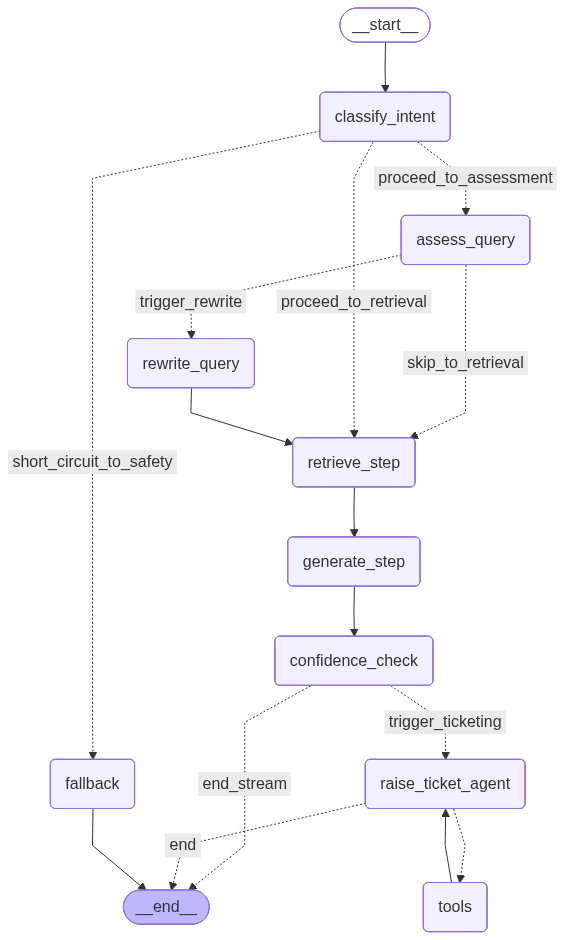

In [607]:
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable" : {"thread_id" : "session_1"}}

graph.invoke({"input" : "What is this error ERR_5GC_UPF_TIMEOUT_504 "}, config)


-- Step 1: Classifying Intent & Product --

Classified intent :Technical_Support 

 Product Identified: AMN-5GC

--Query assessment node running--
Rewrite required -> True
Conditional router: directing to Query_rewrite_node

-- Generating Multi-Query Rewrites --
Generated search variations: ['AMN-5GC troubleshooting ERR_5GC_UPF_TIMEOUT_504 root cause analysis and resolution', 'AMN-5GC standard operating procedure for handling UPF gateway timeout 504 errors', 'AMN-5GC engineering design documentation for UPF connectivity timeouts and architectural resilience strategies', 'What is this error ERR_5GC_UPF_TIMEOUT_504 and what are the engineering apporach of the company']
--Step 2: Retrieving Documents --
---SESSION ID : session_1
Directing MMR Search to isolate product catalog: AMN-5GC
Running similarity searches for 4 query profiles..
Total unique document blocks collected for Generation: 1
--Step 3: Generate Answers --
Answering the question based on: 1 chunks

 Grader Ouput: {
    "con

{'input': 'What is this error ERR_5GC_UPF_TIMEOUT_504 and what are the engineering apporach of the company',
 'messages': [AIMessage(content='I am an automated technical support assistant optimized exclusively for Amantya Technologies and its core product infrastructure suite. I cannot answer external general knowledge queries or perform tasks unrelated to our enterprise systems.', additional_kwargs={}, response_metadata={}, id='742f2bf0-05d9-4ab0-8cf0-94613cadd781', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='The `ERR_5GC_UPF_TIMEOUT_504` error occurs when the Session Management Function (SMF) fails to receive an N4 heartbeat acknowledgment from the User Plane Function (UPF) within 250ms. \n\nThis is typically caused by a CPU core isolation breakdown or a saturated DPDK ring buffer. To resolve this, please follow these steps:\n1. Access the orchestration terminal and verify your core isolation settings using `lscpu --extended`.\n2. Flush the packet interface by running